In [1]:
!pip -q install contractions emoji xgboost wordcloud transformers datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = {
    "text": [
        "I absolutely loved this movie, it was fantastic!",
        "The movie was boring and a complete waste of time.",
        "Amazing product, I am very happy with my purchase.",
        "Terrible service, I will never come back again.",
        "The food was delicious and the staff were wonderful.",
        "I hated the experience, everything was awful.",
        "This is one of the best books I have ever read.",
        "The product stopped working after one day.",
        "Excellent customer service and very friendly staff.",
        "I am disappointed with the quality of this product.",
        "What a wonderful experience, I really enjoyed it.",
        "The movie was horrible and extremely boring.",
        "The hotel room was clean and comfortable.",
        "The hotel was dirty and uncomfortable.",
        "I strongly recommend this product to everyone.",
        "I would not recommend this product to anyone.",
        "The app is easy to use and works perfectly.",
        "The application crashes constantly and is useless.",
        "The teacher explained everything clearly and patiently.",
        "The lecture was confusing and poorly organized.",
        "I am very satisfied with the service.",
        "I am extremely unhappy with the service.",
        "The new phone has an excellent camera.",
        "The phone battery is terrible and dies quickly.",
        "This restaurant serves delicious food.",
        "The restaurant was disappointing and expensive.",
        "I had a great experience shopping here.",
        "The shopping experience was horrible.",
        "The customer support team solved my problem quickly.",
        "Customer support was rude and completely unhelpful.",
        "The quality is outstanding for the price.",
        "The quality is extremely poor.",
        "I enjoyed every minute of this experience.",
        "I regret buying this product.",
        "The design is beautiful and modern.",
        "The design looks cheap and outdated.",
        "This is an excellent service.",
        "This is the worst service I have ever used.",
        "I am happy with the results.",
        "I am unhappy with the results.",
        "The performance is impressive.",
        "The performance is disappointing.",
        "I would definitely buy this again.",
        "I would never buy this again.",
        "The staff were kind and helpful.",
        "The staff were rude and unhelpful.",
        "The experience exceeded my expectations.",
        "The experience was below my expectations.",
        "I love this product.",
        "I hate this product."
    ],
    "sentiment": [
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,0,1,0
    ]
}

df = pd.DataFrame(data)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (50, 2)


,text,sentiment
0,"I absolutely loved this movie, it was fantastic!",1
1,The movie was boring and a complete waste of t...,0
2,"Amazing product, I am very happy with my purch...",1
3,"Terrible service, I will never come back again.",0
4,The food was delicious and the staff were wond...,1


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (50, 2)

Columns:
['text', 'sentiment']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       50 non-null     object
 1   sentiment  50 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 932.0+ bytes

Missing Values:
text         0
sentiment    0
dtype: int64


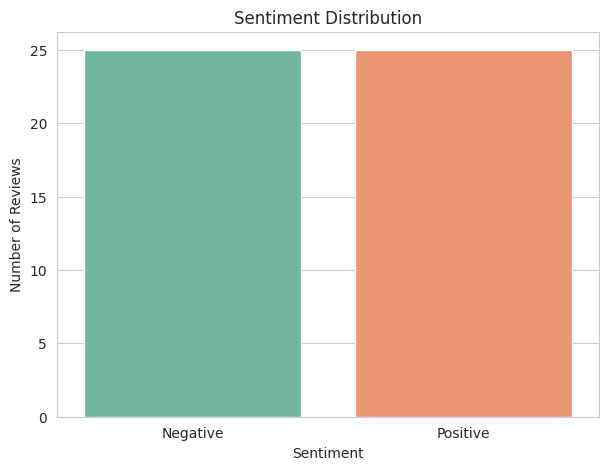

In [5]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sentiment",
    hue="sentiment",
    palette="Set2",
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks([0,1], ["Negative", "Positive"])

plt.show()



In [6]:
df["text_length"] = df["text"].apply(len)
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print(df[["text_length", "word_count"]].describe())

       text_length  word_count
count      50.0000   50.000000
mean       40.4600    6.760000
std         8.5122    1.559173
min        20.0000    4.000000
25%        34.2500    6.000000
50%        41.0000    7.000000
75%        47.0000    7.750000
max        55.0000   11.000000


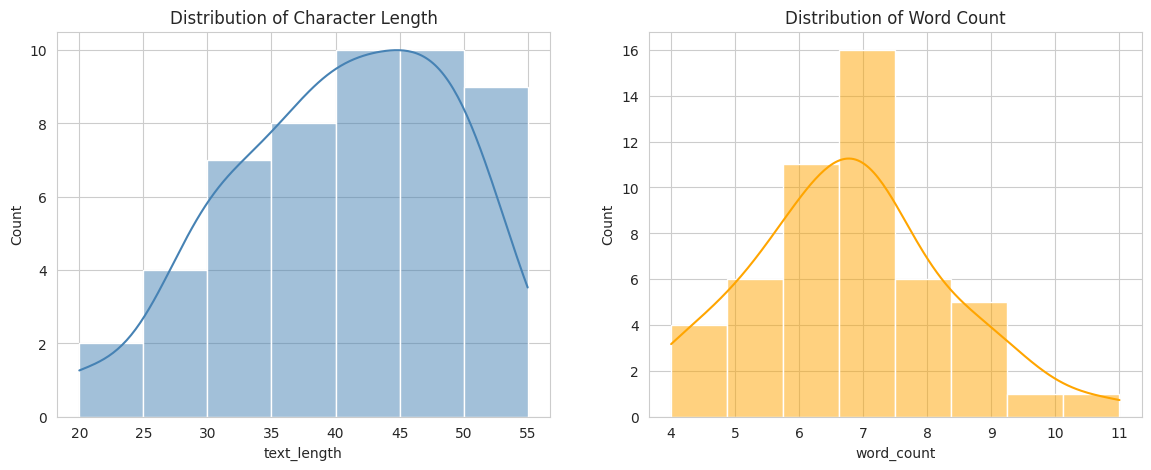

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(
    df["text_length"],
    kde=True,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Distribution of Character Length")

sns.histplot(
    df["word_count"],
    kde=True,
    ax=axes[1],
    color="orange"
)

axes[1].set_title("Distribution of Word Count")

plt.show()

In [8]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

print("Stopwords:", list(stop_words)[:20])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Stopwords: ['most', 'wasn', 'having', 'shouldn', 'about', 'being', 'between', 'mustn', 'while', 'themselves', 'o', "we're", 'by', 'from', 'if', 'isn', 'more', 'other', "i'd", 'ourselves']


In [9]:
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol but keep word
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head(10)

,text,clean_text
0,"I absolutely loved this movie, it was fantastic!",absolutely loved movie fantastic
1,The movie was boring and a complete waste of t...,movie boring complete waste time
2,"Amazing product, I am very happy with my purch...",amazing product happy purchase
3,"Terrible service, I will never come back again.",terrible service never come back
4,The food was delicious and the staff were wond...,food delicious staff wonderful
5,"I hated the experience, everything was awful.",hated experience everything awful
6,This is one of the best books I have ever read.,one best books ever read
7,The product stopped working after one day.,product stopped working one day
8,Excellent customer service and very friendly s...,excellent customer service friendly staff
9,I am disappointed with the quality of this pro...,disappointed quality product


In [10]:
stemmer = PorterStemmer()

def stem_text(text):
    words = word_tokenize(text)

    stemmed_words = [
        stemmer.stem(word)
        for word in words
    ]

    return " ".join(stemmed_words)

df["stemmed_text"] = df["clean_text"].apply(stem_text)

df[["clean_text", "stemmed_text"]].head(10)

,clean_text,stemmed_text
0,absolutely loved movie fantastic,absolut love movi fantast
1,movie boring complete waste time,movi bore complet wast time
2,amazing product happy purchase,amaz product happi purchas
3,terrible service never come back,terribl servic never come back
4,food delicious staff wonderful,food delici staff wonder
5,hated experience everything awful,hate experi everyth aw
6,one best books ever read,one best book ever read
7,product stopped working one day,product stop work one day
8,excellent customer service friendly staff,excel custom servic friendli staff
9,disappointed quality product,disappoint qualiti product


In [11]:
stemmer = PorterStemmer()

def stem_text(text):
    words = word_tokenize(text)

    stemmed_words = [
        stemmer.stem(word)
        for word in words
    ]

    return " ".join(stemmed_words)

df["stemmed_text"] = df["clean_text"].apply(stem_text)

df[["clean_text", "stemmed_text"]].head(10)

,clean_text,stemmed_text
0,absolutely loved movie fantastic,absolut love movi fantast
1,movie boring complete waste time,movi bore complet wast time
2,amazing product happy purchase,amaz product happi purchas
3,terrible service never come back,terribl servic never come back
4,food delicious staff wonderful,food delici staff wonder
5,hated experience everything awful,hate experi everyth aw
6,one best books ever read,one best book ever read
7,product stopped working one day,product stop work one day
8,excellent customer service friendly staff,excel custom servic friendli staff
9,disappointed quality product,disappoint qualiti product


In [12]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    words = text.split()

    # Stopword removal
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Stemming
    words = [
        stemmer.stem(word)
        for word in words
    ]

    return " ".join(words)

df["processed_text"] = df["text"].apply(preprocess_text)

df[["text", "processed_text"]].head(10)

,text,processed_text
0,"I absolutely loved this movie, it was fantastic!",absolut love movi fantast
1,The movie was boring and a complete waste of t...,movi bore complet wast time
2,"Amazing product, I am very happy with my purch...",amaz product happi purchas
3,"Terrible service, I will never come back again.",terribl servic never come back
4,The food was delicious and the staff were wond...,food delici staff wonder
5,"I hated the experience, everything was awful.",hate experi everyth aw
6,This is one of the best books I have ever read.,one best book ever read
7,The product stopped working after one day.,product stop work one day
8,Excellent customer service and very friendly s...,excel custom servic friendli staff
9,I am disappointed with the quality of this pro...,disappoint qualiti product


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["target"] = label_encoder.fit_transform(df["sentiment"])

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded values:")
print(df[["sentiment", "target"]].head())

Classes:
[0 1]

Encoded values:
   sentiment  target
0          1       1
1          0       0
2          1       1
3          0       0
4          1       1


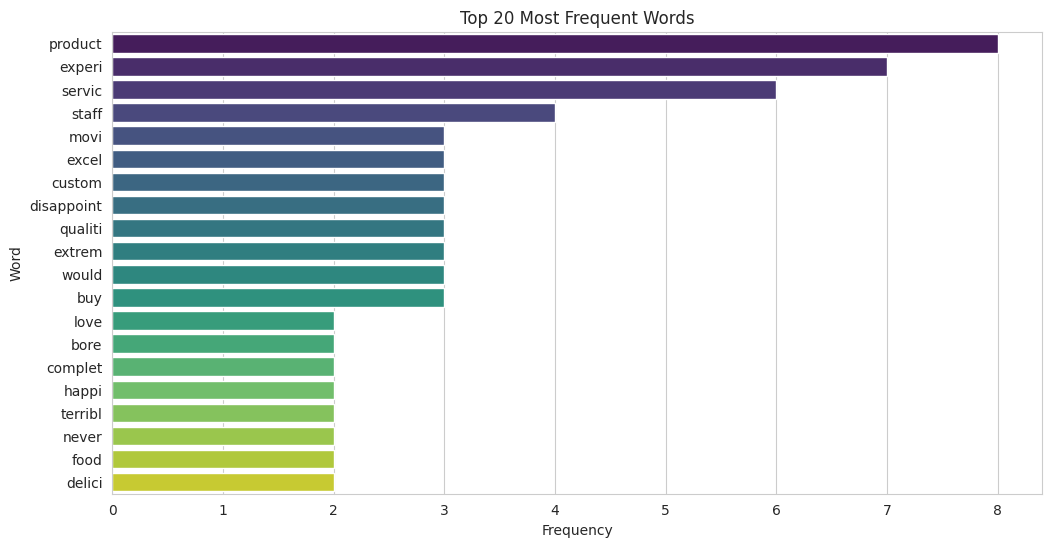

In [14]:
all_words = " ".join(df["processed_text"]).split()

word_frequency = Counter(all_words)

common_words = word_frequency.most_common(20)

words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts,
    y=words,
    hue=words,
    palette="viridis",
    legend=False
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

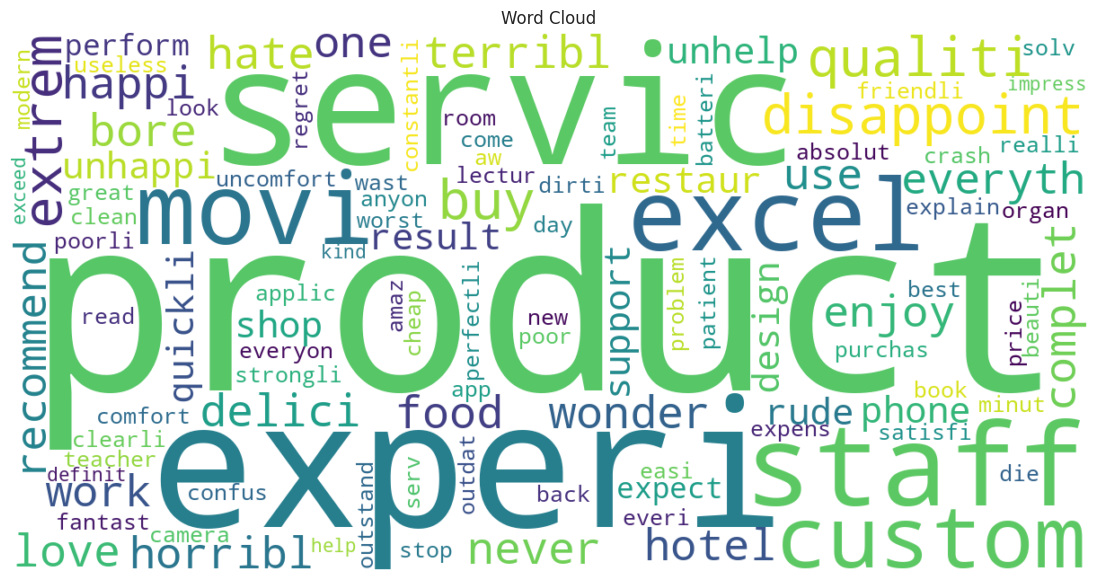

In [15]:
from wordcloud import WordCloud

text_for_wordcloud = " ".join(df["processed_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text_for_wordcloud)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = df["processed_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40
Testing samples: 10


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_count = vectorizer.fit_transform(X_train)
X_test_count = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Training matrix shape:", X_train_count.shape)

Vocabulary size: 97
Training matrix shape: (40, 97)


In [18]:
parameters = [
    {"min_df": 1, "ngram_range": (1,1)},
    {"min_df": 1, "ngram_range": (1,2)},
    {"min_df": 2, "ngram_range": (1,1)},
    {"min_df": 1, "max_features": 50}
]

for params in parameters:

    cv = CountVectorizer(**params)
    matrix = cv.fit_transform(X_train)

    print(
        params,
        "=> Vocabulary:",
        len(cv.vocabulary_),
        "Shape:",
        matrix.shape
    )

{'min_df': 1, 'ngram_range': (1, 1)} => Vocabulary: 97 Shape: (40, 97)
{'min_df': 1, 'ngram_range': (1, 2)} => Vocabulary: 200 Shape: (40, 200)
{'min_df': 2, 'ngram_range': (1, 1)} => Vocabulary: 30 Shape: (40, 30)
{'min_df': 1, 'max_features': 50} => Vocabulary: 50 Shape: (40, 50)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=1000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (40, 200)
TF-IDF testing shape: (10, 200)


In [20]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

In [21]:
embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:

    for line in f:
        values = line.split()

        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")

        embedding_index[word] = vector

print("Number of words:", len(embedding_index))

Number of words: 400000


In [22]:
def glove_vector(sentence):

    words = sentence.split()

    vectors = [
        embedding_index[word]
        for word in words
        if word in embedding_index
    ]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_train_glove = np.array(
    [glove_vector(text) for text in X_train]
)

X_test_glove = np.array(
    [glove_vector(text) for text in X_test]
)

print("GloVe train shape:", X_train_glove.shape)
print("GloVe test shape:", X_test_glove.shape)

GloVe train shape: (40, 100)
GloVe test shape: (10, 100)


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model_name, y_true, y_pred):

    print("\n" + "="*50)
    print(model_name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

In [24]:
from sklearn.naive_bayes import MultinomialNB

nb_dtm = MultinomialNB()

nb_dtm.fit(
    X_train_count,
    y_train
)

pred_nb_dtm = nb_dtm.predict(X_test_count)

evaluate_model(
    "Naive Bayes - DTM",
    y_test,
    pred_nb_dtm
)


Naive Bayes - DTM
Accuracy : 0.6
Precision: 0.6
Recall   : 0.6
F1 Score : 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10



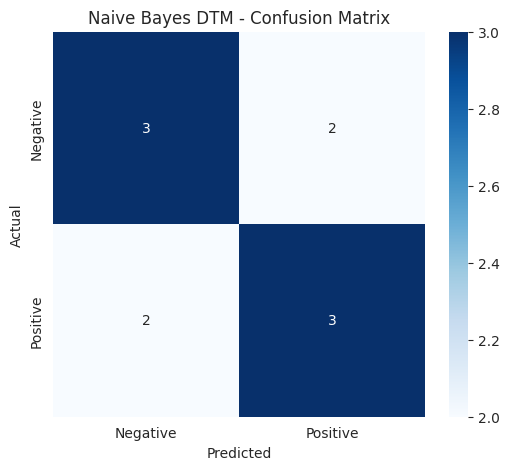

In [25]:
cm = confusion_matrix(y_test, pred_nb_dtm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Naive Bayes DTM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(
    X_train_tfidf,
    y_train
)

pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

evaluate_model(
    "Naive Bayes - TF-IDF",
    y_test,
    pred_nb_tfidf
)


Naive Bayes - TF-IDF
Accuracy : 0.6
Precision: 0.6
Recall   : 0.6
F1 Score : 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10



In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_tfidf,
    y_train
)

pred_xgb = xgb_model.predict(X_test_tfidf)

evaluate_model(
    "XGBoost - TF-IDF",
    y_test,
    pred_xgb
)


XGBoost - TF-IDF
Accuracy : 0.4
Precision: 0.42857142857142855
Recall   : 0.6
F1 Score : 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.20      0.25         5
           1       0.43      0.60      0.50         5

    accuracy                           0.40        10
   macro avg       0.38      0.40      0.38        10
weighted avg       0.38      0.40      0.38        10



In [28]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes - DTM",
        "Naive Bayes - TF-IDF",
        "XGBoost - TF-IDF"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_nb_dtm),
        accuracy_score(y_test, pred_nb_tfidf),
        accuracy_score(y_test, pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, pred_nb_dtm, zero_division=0),
        f1_score(y_test, pred_nb_tfidf, zero_division=0),
        f1_score(y_test, pred_xgb, zero_division=0)
    ]
})

results

,Model,Accuracy,F1 Score
0,Naive Bayes - DTM,0.6,0.6
1,Naive Bayes - TF-IDF,0.6,0.6
2,XGBoost - TF-IDF,0.4,0.5


In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=30
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=30
)

print(X_train_seq.shape)
print(X_test_seq.shape)

(40, 30)
(10, 30)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

lstm_model = Sequential([
    Embedding(5000, 64, input_length=30),
    LSTM(32),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = lstm_model.fit(
    X_train_seq,
    y_train,
    epochs=5,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 351ms/step - accuracy: 0.4062 - loss: 0.6958 - val_accuracy: 0.2500 - val_loss: 0.7042
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.5625 - loss: 0.6884 - val_accuracy: 0.2500 - val_loss: 0.7178
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.5625 - loss: 0.6887 - val_accuracy: 0.2500 - val_loss: 0.7287
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5625 - loss: 0.6799 - val_accuracy: 0.2500 - val_loss: 0.7408
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5625 - loss: 0.6768 - val_accuracy: 0.2500 - val_loss: 0.7493


In [31]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_seq,
    y_test,
    verbose=0
)

print("LSTM Accuracy:", lstm_acc)

LSTM Accuracy: 0.5


In [32]:
!pip -q install transformers

In [33]:
from transformers import pipeline

bert = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [34]:
bert_results = bert(
    df["text"].tolist()
)

bert_pred = [
    1 if result["label"] == "POSITIVE" else 0
    for result in bert_results
]

from sklearn.metrics import accuracy_score

print(
    "BERT Accuracy:",
    accuracy_score(df["target"], bert_pred)
)

BERT Accuracy: 0.98


In [35]:
disaster_data = {
    "text": [
        "Massive earthquake destroyed buildings",
        "Flood destroyed many houses",
        "Firefighters are fighting a huge fire",
        "Explosion injured several people",
        "Hurricane caused major destruction",
        "Rescue teams are searching for survivors",
        "Tornado destroyed homes",
        "Building collapsed after earthquake",
        "People were injured in the accident",
        "Emergency services are responding",

        "I am going shopping today",
        "I love eating pizza",
        "Watching a movie with friends",
        "The weather is beautiful",
        "My cat is sleeping",
        "Going to the gym today",
        "I am cooking dinner",
        "My team won the match",
        "I bought new shoes",
        "Having coffee with friends"
    ],

    "target": [1]*10 + [0]*10
}

disaster_df = pd.DataFrame(disaster_data)

print("Shape:", disaster_df.shape)
print(disaster_df["target"].value_counts())

Shape: (20, 2)
target
1    10
0    10
Name: count, dtype: int64


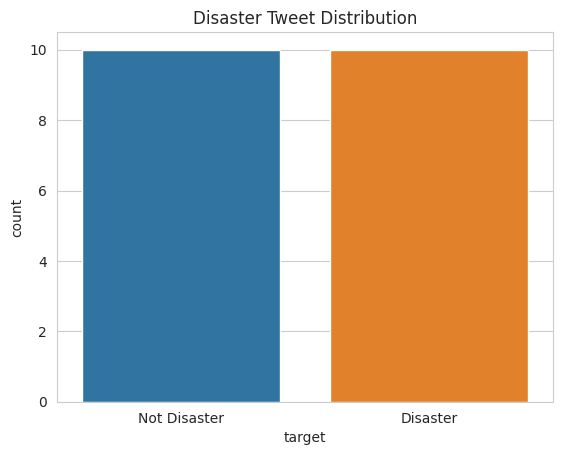

In [36]:
sns.countplot(
    data=disaster_df,
    x="target",
    hue="target",
    legend=False
)

plt.xticks(
    [0, 1],
    ["Not Disaster", "Disaster"]
)

plt.title("Disaster Tweet Distribution")
plt.show()

In [37]:
disaster_df["clean_text"] = (
    disaster_df["text"].apply(preprocess_text)
)

disaster_df.head()

,text,target,clean_text
0,Massive earthquake destroyed buildings,1,massiv earthquak destroy build
1,Flood destroyed many houses,1,flood destroy mani hous
2,Firefighters are fighting a huge fire,1,firefight fight huge fire
3,Explosion injured several people,1,explos injur sever peopl
4,Hurricane caused major destruction,1,hurrican caus major destruct


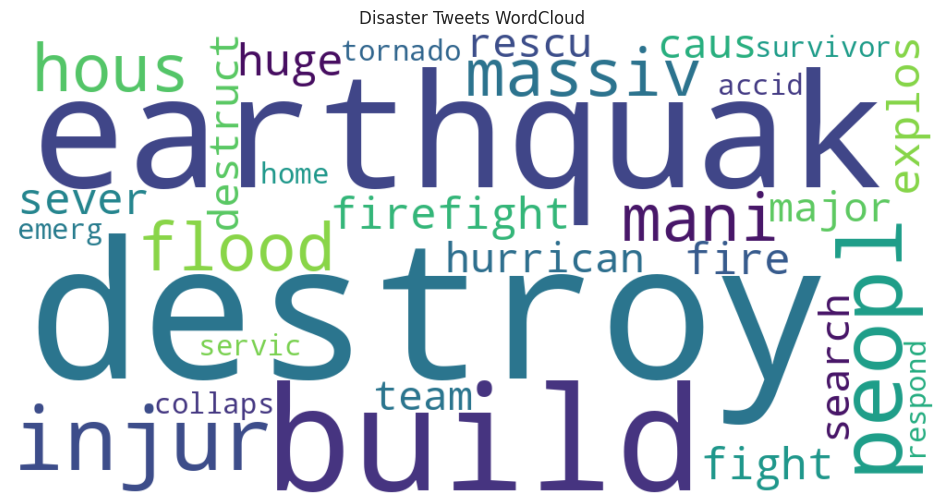

In [38]:
from wordcloud import WordCloud

text = " ".join(
    disaster_df[
        disaster_df["target"] == 1
    ]["clean_text"]
)

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Disaster Tweets WordCloud")
plt.show()

In [39]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    disaster_df["clean_text"],
    disaster_df["target"],
    test_size=0.2,
    random_state=42,
    stratify=disaster_df["target"]
)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

disaster_tfidf = TfidfVectorizer(
    ngram_range=(1,2)
)

Xd_train_vec = disaster_tfidf.fit_transform(Xd_train)
Xd_test_vec = disaster_tfidf.transform(Xd_test)

print(Xd_train_vec.shape)

(16, 75)


In [41]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

disaster_model = MultinomialNB()

disaster_model.fit(
    Xd_train_vec,
    yd_train
)

disaster_pred = disaster_model.predict(
    Xd_test_vec
)

print(classification_report(
    yd_test,
    disaster_pred
))

print(
    "Disaster Tweet Accuracy:",
    accuracy_score(yd_test, disaster_pred)
)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4

Disaster Tweet Accuracy: 0.75


In [42]:
disaster_tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<OOV>"
)

disaster_tokenizer.fit_on_texts(Xd_train)

Xd_train_seq = pad_sequences(
    disaster_tokenizer.texts_to_sequences(Xd_train),
    maxlen=30
)

Xd_test_seq = pad_sequences(
    disaster_tokenizer.texts_to_sequences(Xd_test),
    maxlen=30
)

In [43]:
glove_lstm = Sequential([
    Embedding(5000, 64, input_length=30),
    LSTM(32),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

glove_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

glove_history = glove_lstm.fit(
    Xd_train_seq,
    yd_train,
    epochs=5,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6667 - loss: 0.6875 - val_accuracy: 0.2500 - val_loss: 0.6986
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5833 - loss: 0.7002 - val_accuracy: 0.2500 - val_loss: 0.7002
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5833 - loss: 0.6804 - val_accuracy: 0.2500 - val_loss: 0.7054
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5833 - loss: 0.6875 - val_accuracy: 0.2500 - val_loss: 0.7096
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5833 - loss: 0.6793 - val_accuracy: 0.2500 - val_loss: 0.7143


In [44]:
loss, glove_lstm_acc = glove_lstm.evaluate(
    Xd_test_seq,
    yd_test,
    verbose=0
)

print(
    "Embedding-LSTM Accuracy:",
    glove_lstm_acc
)

Embedding-LSTM Accuracy: 0.5


In [45]:
print("=" * 40)
print("FINAL MODEL RESULTS")
print("=" * 40)

print(
    "LSTM Accuracy:",
    lstm_acc
)

print(
    "BERT Accuracy:",
    accuracy_score(df["target"], bert_pred)
)

print(
    "Disaster Naive Bayes Accuracy:",
    accuracy_score(yd_test, disaster_pred)
)

print(
    "Disaster LSTM Accuracy:",
    glove_lstm_acc
)

FINAL MODEL RESULTS
LSTM Accuracy: 0.5
BERT Accuracy: 0.98
Disaster Naive Bayes Accuracy: 0.75
Disaster LSTM Accuracy: 0.5


In [46]:
print("""
CONCLUSION

This project implemented an end-to-end NLP pipeline.

The major steps included:
- Text preprocessing
- Stemming
- Target encoding
- Token visualization
- CountVectorizer
- TF-IDF
- GloVe/word embedding concepts
- Naive Bayes
- XGBoost
- LSTM
- BERT
- Disaster Tweet classification
- WordCloud
- LSTM-based disaster classification

Traditional machine learning and deep learning approaches
were compared for text classification.
""")


CONCLUSION

This project implemented an end-to-end NLP pipeline.

The major steps included:
- Text preprocessing
- Stemming
- Target encoding
- Token visualization
- CountVectorizer
- TF-IDF
- GloVe/word embedding concepts
- Naive Bayes
- XGBoost
- LSTM
- BERT
- Disaster Tweet classification
- WordCloud
- LSTM-based disaster classification

Traditional machine learning and deep learning approaches
were compared for text classification.

